In [1]:
# """

# This notebook is a template for computing the common lines matrix. Examples are
# 1) Synthetic data using images genereated from Aspire
# 2) Real data from Verbeke et al 2019, JSB

# TODO
# - *** Need to rescale input volumes to have the same initial resolution (e.g. 3A/vox)
# - add code to compute the A matrix from the gt rotations for synthetic data
# - add function to check that theta_ij is correctly estimated

# """

In [2]:
import os
import time
import pickle
import logging

import cl_utils as cl

import mrcfile
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

from aspire.image import Image
from aspire.noise import WhiteNoiseAdder
from aspire.operators import ScalarFilter
from aspire.source.simulation import Simulation
from aspire.source import ArrayImageSource
from aspire.utils import Rotation, gaussian_2d
from aspire.volume import Volume

/home/ev9102/.conda/envs/aspire/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
###############################

# Example with synthetic data #

###############################

In [4]:
### Inputs ###

DATA_DIR = '/scratch/network/ev9102/Data/'  # set the input directory with your EMDBs
emd_ids = ['emd_8443.map', 'emd_21995.map']  # e.g. 50S ribosome, beta-galactosidase
n_img = [5, 5]  # number of images for each structure
L = 64  # size to downsample the volume
snr = 10  # snr for additive wgn to projection images
add_mask = True  # add circular mask to images
mask_radius = L//2  # in pixels
use_noisy = False  # option to use the noisy images of clean images
angles = np.arange(0, 360, 1)  # angular sampling for line projections
r = np.array([cl.get_random_euler_angles(n) for n in n_img])  # pick Euler angles (in rads) for 'ZYZ' convention

In [5]:
### load volumes ###

logger = logging.getLogger(__name__)

volumes = {}

for i, entry in enumerate(emd_ids):
    volumes[i] = mrcfile.open(os.path.join(DATA_DIR, entry)).data.astype(np.float64)

# # instantiate an Aspire "Volume", which is downsampled to LxLxL
t0 = time.time()
volumes = {k: Volume(v).downsample(L) for k, v in volumes.items()}
print('load volumes: ', time.time() - t0)

load volumes:  106.86010766029358


In [6]:
### create Aspire simulation source to generate synthetic images ###

assert len(emd_ids) == len(n_img), "must be equal length"

rots = [Rotation.from_euler(ri) for ri in r]  # list of rotations in Aspire format
shifts = [np.zeros((n, 2)) for n in n_img]  # not including shifts for now
amplitudes = [np.ones(n) for n in n_img]

src = {
    k: Simulation(vols=v,  # our Volume
                  L=v.resolution,  # resolution, should match Volume
                  n=n_img[idx],  # number of projection images
                  angles=rots[idx].angles,  # pass our rotations as Euler angles
                  offsets=shifts[idx],  # translations (wrt to origin)
                  amplitudes=amplitudes[idx],  # amplification ( 1 is identity)
                  noise_adder=WhiteNoiseAdder.from_snr(snr=snr),
                  seed=12345,  # RNG seed for reproducibility
                  dtype=v.dtype  # match our datatype to the Volume.
                 )
    for k, (idx, v) in enumerate(volumes.items())
}

### make the final image stack, simplify this later

clean_images = {k: s.projections[:n_img[idx]].asnumpy().copy() for k, (idx, s) in enumerate(src.items())}

noisy_images = {k: s.images[:n_img[idx]].asnumpy().copy() for k, (idx, s) in enumerate(src.items())}

if add_mask:
    rdists = cl.radial_distance_grid([L, L])
    mask = cl.sphere_mask(rdists, mask_radius)
    for k, imgs in clean_images.items():
        for idx, img in enumerate(imgs):
            clean_images[k][idx] = mask * img 
    for k, imgs in noisy_images.items():
        for idx, img in enumerate(imgs):
            noisy_images[k][idx] = mask * img 

images = []

if use_noisy:
    for k, imgs in noisy_images.items():
        for img in imgs:
            images.append(img)
else:
    for k, imgs in clean_images.items():
        for img in imgs:
            images.append(img)
            
images = np.array(images)

2023-09-25 14:06:49,408 INFO [aspire.source.image] Creating Simulation with 5 images.
2023-09-25 14:06:49,413 INFO [aspire.source.simulation] Appending WhiteNoiseAdder with variance=None to generation pipeline


100%|██████████| 1/1 [00:00<00:00,  8.41it/s]

2023-09-25 14:06:49,539 INFO [aspire.source.image] Creating Simulation with 5 images.
2023-09-25 14:06:49,541 INFO [aspire.source.simulation] Appending WhiteNoiseAdder with variance=None to generation pipeline



100%|██████████| 1/1 [00:00<00:00, 11.76it/s]


In [7]:
### compute the line projection distances and form common lines matrix
### format is (img1, img2) : (theta1, theta2) --> angles to rotate for common lines using np conventions

n_total = images.shape[0]

t0 = time.time()
cl_angles = cl.compute_common_line_angles(images, angles)
print('compute cl distances: ', time.time() - t0)

### now form A, the common lines matrix

A = cl.form_cl_matrix_from_cl_angles(cl_angles, n_total)

compute cl distances:  1.4876184463500977


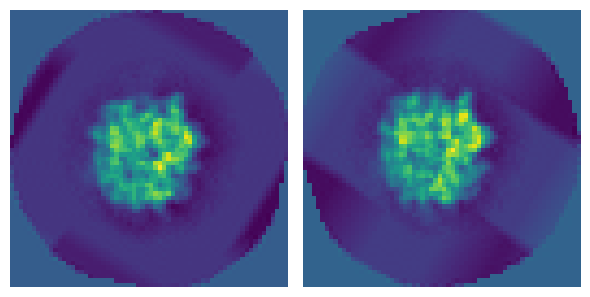

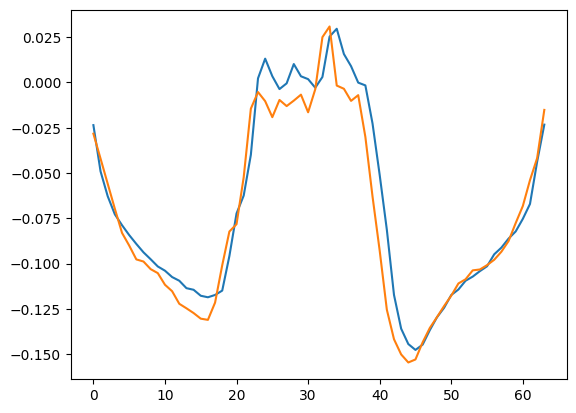

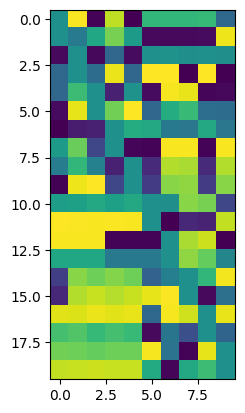

In [8]:
### plotting ###
idx1 = 0 
idx2 = 1

a1 = cl_angles[(idx1, idx2)][0]
a2 = cl_angles[(idx1, idx2)][1]
img1 = ndi.rotate(images[idx1], a1, reshape=False)
img2 = ndi.rotate(images[idx2], a2, reshape=False)
cl.two_plot(img1, img2, size=6)

plt.plot(img1.sum(axis=0))
plt.plot(img2.sum(axis=0))
plt.show()

plt.imshow(A)
plt.show()

In [9]:
### save matrix to matlab format
# from scipy.io import savemat
# cl_mat_dict = {'A': A}
# savemat('A.mat', cl_mat_dict)

In [10]:
###############################

#   Example with real data    #

###############################

In [11]:
### notes
### - the common lines distances in the original paper included region extraction and shifting of the line projections
### - add clustering here?
### - is it worth parallelizing or trying EMD?

In [12]:
mrcs = 'Data/mixture_2D.mrcs'

images = []

with mrcfile.open(mrcs) as mrc:
    for data in mrc.data:
        images.append(data)
    mrc.close()
    
images = np.array(images)

with open('Data/mixture_labels.pkl', 'rb') as f:
    labels = pickle.load(f)

with open('Data/mixture_clusters.pkl', 'rb') as f:
    clusters = pickle.load(f)

In [13]:
n_total = images.shape[0]

t0 = time.time()
cl_angles = cl.compute_common_line_angles(images, angles)
print('compute cl distances: ', time.time() - t0)

### now form A, the common lines matrix

A = cl.form_cl_matrix_from_cl_angles(cl_angles, n_total)

compute cl distances:  239.4979796409607


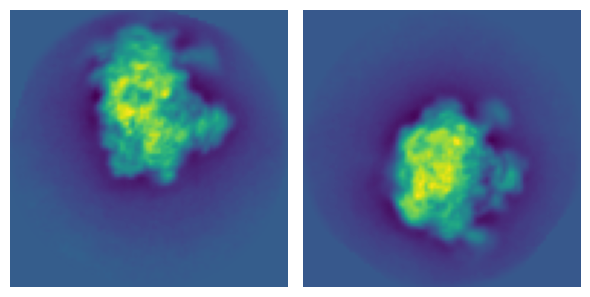

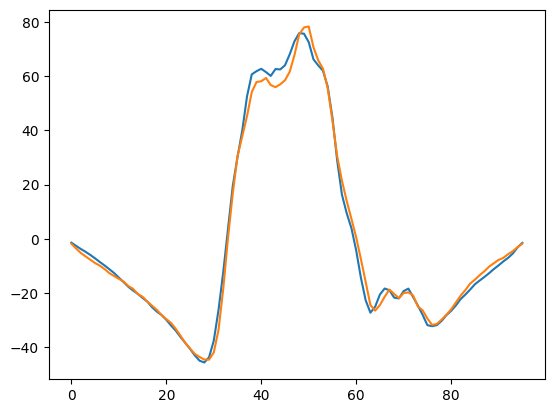

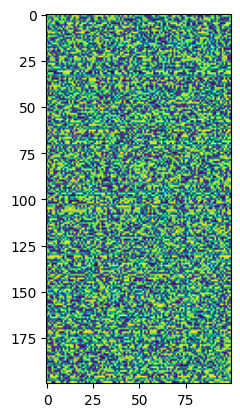

In [14]:
### plotting ###
idx1 = 84 
idx2 = 88

a1 = cl_angles[(idx1, idx2)][0]
a2 = cl_angles[(idx1, idx2)][1]
img1 = ndi.rotate(images[idx1], a1, reshape=False)
img2 = ndi.rotate(images[idx2], a2, reshape=False)
cl.two_plot(img1, img2, size=6)

plt.plot(img1.sum(axis=0))
plt.plot(img2.sum(axis=0))
plt.show()

plt.imshow(A)
plt.show()

In [ ]:
### save matrix to matlab format
# from scipy.io import savemat
# cl_mat_dict = {'A': A}
# savemat('A.mat', cl_mat_dict)

In [15]:
clusters[1], labels['40S']

([12, 48, 53, 54, 60, 64, 70, 73, 75, 91, 92], [22, 64, 73, 75, 91, 92])